In [ ]:
!pip install category_encoders

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.9/85.9 kB 6.7 MB/s eta 0:00:00


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
file_name = '/content/drive/MyDrive/Colab Notebooks/fake_job_postings.csv'
df = pd.read_csv(file_name, encoding='utf-8')
df=df.fillna('')
df.head()

,job_id,title,location,department,salary_range,company_profile,description,requirements,benefits,telecommuting,has_company_logo,has_questions,employment_type,required_experience,required_education,industry,function,fraudulent
0,1,Marketing Intern,"US, NY, New York",Marketing,,"We're Food52, and we've created a groundbreaki...","Food52, a fast-growing, James Beard Award-winn...",Experience with content management systems a m...,,0,1,0,Other,Internship,,,Marketing,0
1,2,Customer Service - Cloud Video Production,"NZ, , Auckland",Success,,"90 Seconds, the worlds Cloud Video Production ...",Organised - Focused - Vibrant - Awesome!Do you...,What we expect from you:Your key responsibilit...,What you will get from usThrough being part of...,0,1,0,Full-time,Not Applicable,,Marketing and Advertising,Customer Service,0
2,3,Commissioning Machinery Assistant (CMA),"US, IA, Wever",,,Valor Services provides Workforce Solutions th...,"Our client, located in Houston, is actively se...",Implement pre-commissioning and commissioning ...,,0,1,0,,,,,,0
3,4,Account Executive - Washington DC,"US, DC, Washington",Sales,,Our passion for improving quality of life thro...,THE COMPANY: ESRI – Environmental Systems Rese...,"EDUCATION: Bachelor’s or Master’s in GIS, busi...",Our culture is anything but corporate—we have ...,0,1,0,Full-time,Mid-Senior level,Bachelor's Degree,Computer Software,Sales,0
4,5,Bill Review Manager,"US, FL, Fort Worth",,,SpotSource Solutions LLC is a Global Human Cap...,JOB TITLE: Itemization Review ManagerLOCATION:...,QUALIFICATIONS:RN license in the State of Texa...,Full Benefits Offered,0,1,1,Full-time,Mid-Senior level,Bachelor's Degree,Hospital & Health Care,Health Care Provider,0


In [ ]:
import torch
path = '/content/drive/MyDrive/Colab Notebooks/distilbert_embeddings.pt'

embeddings = torch.load(path)
print(f"Đã tải thành công embeddings. Kích thước: {embeddings.shape}")

Đã tải thành công embeddings. Kích thước: torch.Size([17880, 768])


In [ ]:
embeddings

tensor([[-0.0068, -0.1715, -0.3449,  ..., -0.0064,  0.6597,  0.0131],
        [-0.0643, -0.0489,  0.0889,  ..., -0.0652,  0.3888,  0.1999],
        [-0.1948, -0.0091, -0.0933,  ..., -0.0373,  0.1610,  0.2481],
        ...,
        [-0.2560,  0.0575, -0.0914,  ..., -0.2383,  0.1353,  0.1627],
        [ 0.1411, -0.0064,  0.0165,  ..., -0.2393,  0.3598,  0.0852],
        [ 0.2603, -0.1467, -0.0851,  ..., -0.1206,  0.5061,  0.1111]])

In [ ]:
df_text=pd.DataFrame(embeddings.numpy(), columns=[f'embedding_{i}' for i in range(embeddings.shape[1])])
df_text

,embedding_0,embedding_1,embedding_2,embedding_3,embedding_4,embedding_5,embedding_6,embedding_7,embedding_8,embedding_9,...,embedding_758,embedding_759,embedding_760,embedding_761,embedding_762,embedding_763,embedding_764,embedding_765,embedding_766,embedding_767
0,-0.006825,-0.171511,-0.344916,-0.039389,0.140505,-0.064374,0.038816,0.183106,0.097043,-0.458427,...,-0.156187,-0.244710,-0.332499,-0.183808,0.057629,0.114452,-0.019076,-0.006427,0.659727,0.013115
1,-0.064279,-0.048894,0.088938,-0.047129,-0.004736,-0.081870,0.127946,0.348866,-0.125638,-0.327198,...,0.099090,-0.500471,-0.118714,-0.397737,0.024148,0.296405,-0.045130,-0.065250,0.388773,0.199876
2,-0.194836,-0.009136,-0.093346,-0.058679,0.323132,-0.058331,0.091157,0.237834,0.077299,-0.559568,...,0.146617,-0.355466,0.088994,-0.317151,-0.090106,-0.074721,0.097799,-0.037337,0.160971,0.248085
3,-0.290094,-0.089697,-0.015488,0.128423,0.245929,-0.112090,0.022759,0.451208,-0.207343,-0.446260,...,0.032049,-0.434583,0.121195,-0.155045,0.024756,0.069798,-0.032680,-0.300742,0.417866,0.288775
4,-0.403924,-0.076912,-0.124519,-0.049646,0.233191,0.022091,0.176625,0.075006,0.135238,-0.601973,...,0.010163,-0.530923,0.112992,-0.440626,-0.028085,0.118964,-0.064004,-0.182069,0.357306,0.134956
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17875,0.246743,-0.139848,-0.080720,0.086488,0.149722,-0.171246,0.033524,0.422035,-0.108422,-0.467534,...,-0.062201,-0.411138,-0.071807,-0.218323,0.052213,0.184688,-0.143855,-0.100528,0.478144,0.108507
17876,-0.107236,-0.126082,-0.026762,0.086636,0.181649,-0.015452,0.099833,0.224025,0.063024,-0.267774,...,-0.018679,-0.303669,-0.054740,-0.181203,0.019014,0.010907,-0.038414,-0.166729,0.426953,0.146510
17877,-0.255998,0.057527,-0.091416,0.074108,0.164330,-0.043494,0.172930,0.110075,-0.006118,-0.648579,...,0.209799,-0.345979,-0.001134,-0.348534,-0.064728,0.001352,-0.132200,-0.238324,0.135335,0.162749
17878,0.141056,-0.006378,0.016471,0.062255,0.054234,-0.076543,0.295103,0.276044,-0.022701,-0.587190,...,0.083961,-0.527000,0.088130,-0.327129,0.001546,0.156217,-0.103620,-0.239271,0.359808,0.085238


In [ ]:
text_features = ['title', 'company_profile', 'description', 'requirements', 'benefits']
categorical = ['employment_type', 'required_experience', 'required_education', 'industry', 'function','department','salary_range']
bin = ['telecommuting','has_company_logo','has_questions']

In [ ]:
X = pd.concat([df_text, df[categorical], df[bin]], axis=1)
X.head()

,embedding_0,embedding_1,embedding_2,embedding_3,embedding_4,embedding_5,embedding_6,embedding_7,embedding_8,embedding_9,...,employment_type,required_experience,required_education,industry,function,department,salary_range,telecommuting,has_company_logo,has_questions
0,-0.006825,-0.171511,-0.344916,-0.039389,0.140505,-0.064374,0.038816,0.183106,0.097043,-0.458427,...,Other,Internship,,,Marketing,Marketing,,0,1,0
1,-0.064279,-0.048894,0.088938,-0.047129,-0.004736,-0.081870,0.127946,0.348866,-0.125638,-0.327198,...,Full-time,Not Applicable,,Marketing and Advertising,Customer Service,Success,,0,1,0
2,-0.194836,-0.009136,-0.093346,-0.058679,0.323132,-0.058331,0.091157,0.237834,0.077299,-0.559568,...,,,,,,,,0,1,0
3,-0.290094,-0.089697,-0.015488,0.128423,0.245929,-0.112090,0.022759,0.451208,-0.207343,-0.446260,...,Full-time,Mid-Senior level,Bachelor's Degree,Computer Software,Sales,Sales,,0,1,0
4,-0.403924,-0.076912,-0.124519,-0.049646,0.233191,0.022091,0.176625,0.075006,0.135238,-0.601973,...,Full-time,Mid-Senior level,Bachelor's Degree,Hospital & Health Care,Health Care Provider,,,0,1,1


In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, df['fraudulent'], stratify=df['fraudulent'], test_size=0.2, random_state=12)
print(f"Training Set Shape: {X_train.shape}")
print(f"Test Set Shape: {X_test.shape}")

Training Set Shape: (14304, 778)
Test Set Shape: (3576, 778)


In [ ]:
for cat in categorical:
  print(f'{cat}: {len(df[cat].unique())}')

employment_type: 6
required_experience: 8
required_education: 14
industry: 132
function: 38
department: 1338
salary_range: 875


In [ ]:
X_cat_train = X_train[categorical]
X_cat_test = X_test[categorical]

In [ ]:
import category_encoders as ce
from sklearn.preprocessing import StandardScaler

#Target encoding on categorical features
target_encode = ce.TargetEncoder(cols=X_cat_train.columns.tolist())
X_cat_train_encoded = target_encode.fit_transform(X_cat_train, y_train)
X_cat_test_encoded = target_encode.transform(X_cat_test)

#Normalise the encoded values
scaler = StandardScaler()
X_cat_train_scaled = scaler.fit_transform(X_cat_train_encoded)
X_cat_test_scaled = scaler.transform(X_cat_test_encoded)

In [ ]:
import numpy as np
X_train_array = X_train.iloc[:, :768].to_numpy()
X_test_array = X_test.iloc[:, :768].to_numpy()
X_train_bin = X_train.iloc[:,-3:]
X_test_bin = X_test.iloc[:,-3:]
X_train_final = np.concatenate((X_train_array, X_cat_train_scaled,X_train_bin), axis=1)
X_test_final = np.concatenate((X_test_array, X_cat_test_scaled, X_test_bin), axis=1)
print(X_train_final.shape)
print(X_test_final.shape)

(14304, 778)
(3576, 778)


In [ ]:
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
# To tabulate evluation metrics and compare models with reusable code
def evaluate_model(model, X_test, y_test):
    y_pred = model.predict(X_test)
    return pd.Series({'accuracy': accuracy_score(y_test, y_pred),
                      'precision': precision_score(y_test, y_pred),
                      'recall': recall_score(y_test, y_pred),
                      'f1_score': f1_score(y_test, y_pred)})

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

def plot_cm(y_true, y_pred, title='Confusion Matrix'):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['No scam', 'Scam'],
                yticklabels=['No scam', 'Scam'])

    plt.title(title, fontsize=15)
    plt.xlabel('Nhãn dự đoán', fontsize=12)
    plt.ylabel('Nhãn thực tế', fontsize=12)
    plt.show()

In [ ]:
from sklearn.linear_model import LogisticRegression
lr=LogisticRegression(max_iter=1000)
lr.fit(X_train_final, y_train)
metric = evaluate_model(lr, X_test_final, y_test)
metric

,0
accuracy,0.977069
precision,0.822695
recall,0.670520
f1_score,0.738854


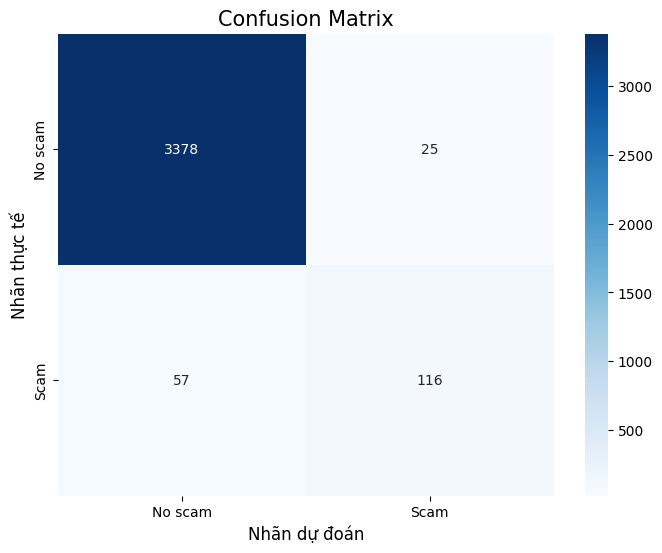

In [ ]:
y_pred_lr = lr.predict(X_test_final)
plot_cm(y_test, y_pred_lr)

In [ ]:
import xgboost as xgb
xgb_clf = xgb.XGBClassifier(n_estimators=75, subsample=0.75, max_depth=7, device='cpu')
xgb_clf.fit(X_train_final, y_train)
metric = evaluate_model(xgb_clf, X_test_final, y_test)
metric

,0
accuracy,0.979027
precision,0.871212
recall,0.664740
f1_score,0.754098


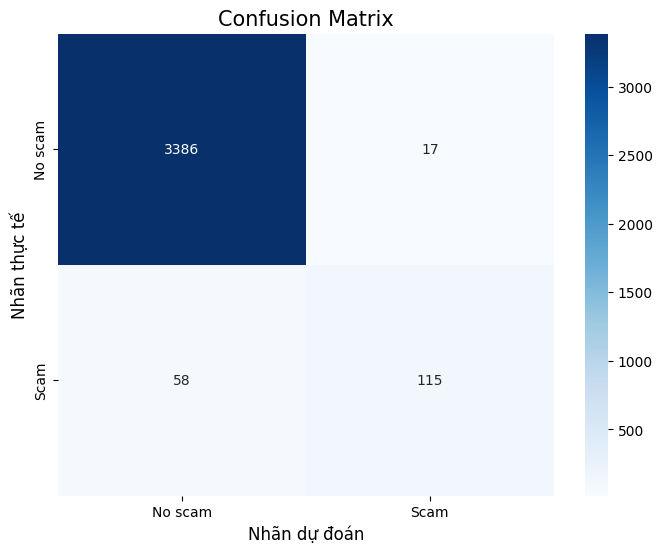

In [ ]:
y_pred_xgb = xgb_clf.predict(X_test_final)
plot_cm(y_test, y_pred_xgb)

In [ ]:
from lightgbm import LGBMClassifier

lgbm_clf = LGBMClassifier(
    n_estimators=100,
    learning_rate=0.1,
    num_leaves=31,
    device='cpu',
    random_state=42
)
lgbm_clf.fit(X_train_final, y_train)
metric = evaluate_model(lgbm_clf, X_test_final, y_test)
metric


[LightGBM] [Info] Number of positive: 693, number of negative: 13611
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.209162 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 196135
[LightGBM] [Info] Number of data points in the train set: 14304, number of used features: 778
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.048448 -> initscore=-2.977604
[LightGBM] [Info] Start training from score -2.977604


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


,0
accuracy,0.979866
precision,0.917355
recall,0.641618
f1_score,0.755102


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


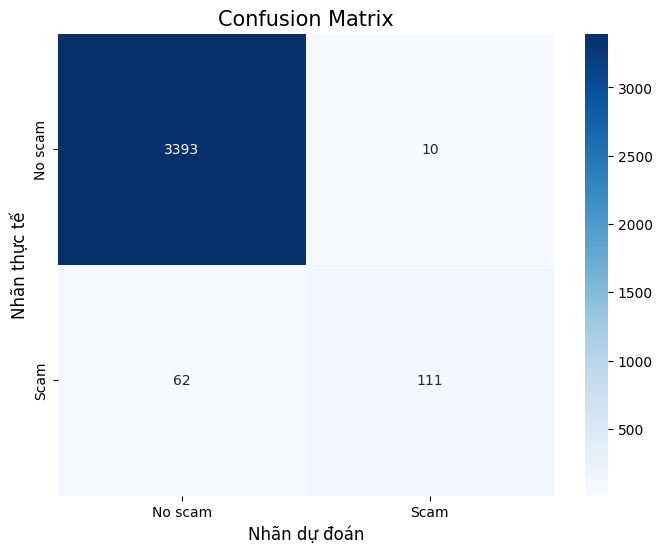

In [ ]:
y_pred_lgbm = lgbm_clf.predict(X_test_final)
plot_cm(y_test, y_pred_lgbm)

In [ ]:
lr=LogisticRegression(max_iter=1000,class_weight='balanced')
lr.fit(X_train_final, y_train)
metric = evaluate_model(lr, X_test_final, y_test)
metric

,0
accuracy,0.961130
precision,0.564885
recall,0.855491
f1_score,0.680460


In [ ]:
ratio = float(sum(y_train == 0)) / sum(y_train == 1)
ratio

19.64069264069264

In [ ]:
xgb_clf = xgb.XGBClassifier(n_estimators=200,
                            min_child_weight = 5,
                            subsample=0.75,
                            max_depth=5,
                            device='cpu',
                            scale_pos_weight=ratio)
xgb_clf.fit(X_train_final, y_train)
metric = evaluate_model(xgb_clf, X_test_final, y_test)
metric

,0
accuracy,0.982662
precision,0.862745
recall,0.763006
f1_score,0.809816


In [ ]:
from lightgbm import LGBMClassifier

lgbm_clf = LGBMClassifier(
    n_estimators=100,
    learning_rate=0.1,
    num_leaves=31,
    is_unbalance=True,
    device='cpu',
    random_state=12
)
lgbm_clf.fit(X_train_final, y_train)
metric = evaluate_model(lgbm_clf, X_test_final, y_test)
metric

[LightGBM] [Info] Number of positive: 693, number of negative: 13611
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.234959 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 196135
[LightGBM] [Info] Number of data points in the train set: 14304, number of used features: 778
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.048448 -> initscore=-2.977604
[LightGBM] [Info] Start training from score -2.977604


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


,0
accuracy,0.982383
precision,0.871622
recall,0.745665
f1_score,0.803738


In [ ]:
pip install imblearn

In [ ]:
from xgboost import XGBClassifier

In [ ]:
from imblearn.over_sampling import SMOTE

In [ ]:
smt = SMOTE()
X_train_resampled, y_train_resampled = smt.fit_resample(X_train_final, y_train)

In [ ]:
print(np.bincount(y_train))
print(np.bincount(y_train_resampled))

[13611   693]
[13611 13611]


In [ ]:
from sklearn.linear_model import LogisticRegression
lr=LogisticRegression(max_iter=1000)
lr.fit(X_train_resampled, y_train_resampled)
metric = evaluate_model(lr, X_test_final, y_test)
metric

,0
accuracy,0.964485
precision,0.592000
recall,0.855491
f1_score,0.699764


In [ ]:
xgb_clf = xgb.XGBClassifier(n_estimators=200,
                        min_child_weight = 5,
                        subsample=0.75,
                        max_depth=5,
                        device='cuda')
xgb_clf.fit(X_train_resampled, y_train_resampled)
metric = evaluate_model(xgb_clf, X_test_final, y_test)
metric

/usr/local/lib/python3.12/dist-packages/xgboost/core.py:751: UserWarning: [04:34:00] WARNING: /__w/xgboost/xgboost/src/common/error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


,0
accuracy,0.982662
precision,0.828402
recall,0.809249
f1_score,0.818713


In [ ]:
from lightgbm import LGBMClassifier

lgbm_clf = LGBMClassifier(
    n_estimators=100,
    learning_rate=0.1,
    num_leaves=31,
    device='cpu',
    random_state=12
)
lgbm_clf.fit(X_train_resampled, y_train_resampled)
metric = evaluate_model(lgbm_clf, X_test_final, y_test)
metric

[LightGBM] [Info] Number of positive: 13611, number of negative: 13611
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.359481 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 198390
[LightGBM] [Info] Number of data points in the train set: 27222, number of used features: 778
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


,0
accuracy,0.978747
precision,0.786982
recall,0.768786
f1_score,0.777778


Fine-tune Logistic Regression

In [ ]:
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 4.9 MB/s eta 0:00:00


In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold
import optuna
import numpy as np
from tqdm import tqdm

X_train_array = np.array(X_train_final)
y_train_array = np.array(y_train)

X_test_array = np.array(X_test_final)
y_test_array = np.array(y_test)

# --- BƯỚC 1: SCALE DỮ LIỆU (BẮT BUỘC CHO LOGISTIC REGRESSION) ---
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_array)

def objective(trial, X, y):
    params = {
        'C': trial.suggest_float('C', 1e-3, 10.0, log=True),
        'penalty': 'elasticnet',
        'l1_ratio': trial.suggest_float('l1_ratio', 0.0, 1.0),
        'solver': 'saga',
        'random_state': 42,
        'n_jobs': -1,
        'max_iter': 1000,
        'tol': 0.01
    }

    # --- BƯỚC 2: Chạy 3-FOLDs Cross-validation---
    cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
    cv_scores = []

    for train_idx, val_idx in cv.split(X, y):
        X_tr, X_val = X[train_idx], X[val_idx]
        y_tr, y_val = y[train_idx], y[val_idx]

        model = LogisticRegression(**params)
        model.fit(X_tr, y_tr)

        preds = model.predict_proba(X_val)[:, 1]
        cv_scores.append(roc_auc_score(y_val, preds))

    return np.mean(cv_scores)

n_trials = 50
pbar = tqdm(total=n_trials, desc="Fast Optimizing LR")

def callback(study, trial):
    pbar.update(1)

study = optuna.create_study(direction='maximize')
study.optimize(lambda trial: objective(trial, X_train_scaled, y_train_array),
               n_trials=n_trials, callbacks=[callback])
pbar.close()


Fast Optimizing LR:   0%|          | 0/50 [02:11<?, ?it/s]

Fast Optimizing LR: 100%|██████████| 50/50 [12:58<00:00, 15.57s/it]


In [ ]:
study.best_params

{'C': 0.21392078227528888, 'l1_ratio': 0.7324475182403097}

In [ ]:
X_train_array = np.array(X_train_final)
y_train_array = np.array(y_train)

X_test_array = np.array(X_test_final)
y_test_array = np.array(y_test)

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import precision_recall_curve, classification_report, roc_auc_score, f1_score
import numpy as np

# 1. Chuẩn bị dữ liệu (Logistic Regression bắt buộc phải Scale)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_array)
X_test_scaled = scaler.transform(X_test_array)

# 2. Huấn luyện model cuối cùng với tham số từ Optuna
# (Đảm bảo dùng solver 'saga' và penalty 'elasticnet' nếu bạn tune theo hướng đó)
final_params = {'C': 0.21392078227528888, 'l1_ratio': 0.7324475182403097, 'solver': 'saga', 'penalty': 'elasticnet', 'max_iter': 2000, 'random_state': 42}
best_lr = LogisticRegression(**final_params)
best_lr.fit(X_train_scaled, y_train_array)

# 3. Tìm ngưỡng (Threshold) tối ưu để Maximize F1-Score
y_probs = best_lr.predict_proba(X_test_scaled)[:, 1]
precisions, recalls, thresholds = precision_recall_curve(y_test_array, y_probs)

# Tính F1 cho từng ngưỡng
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-8)
best_idx = np.argmax(f1_scores)
lr_opt_threshold = thresholds[best_idx]

# 4. Đánh giá toàn diện với ngưỡng vừa tìm được
y_preds = (y_probs >= lr_opt_threshold).astype(int)

print(f"{' LOGISTIC REGRESSION FINAL REPORT ':=^50}")
print(f"Best Threshold found : {lr_opt_threshold:.4f}")
print(f"Final ROC-AUC        : {roc_auc_score(y_test_array, y_probs):.4f}")
print(f"Final F1-Score       : {f1_score(y_test_array, y_preds):.4f}")
print(f"\nClassification Report (at Threshold {lr_opt_threshold:.4f}):")
print(classification_report(y_test_array, y_preds, target_names=['Real (0)', 'Fake (1)']))

======== LOGISTIC REGRESSION FINAL REPORT ========
Best Threshold found : 0.3172
Final ROC-AUC        : 0.9715
Final F1-Score       : 0.7627

Classification Report (at Threshold 0.3172):
              precision    recall  f1-score   support

    Real (0)       0.99      0.99      0.99      3403
    Fake (1)       0.75      0.78      0.76       173

    accuracy                           0.98      3576
   macro avg       0.87      0.88      0.88      3576
weighted avg       0.98      0.98      0.98      3576



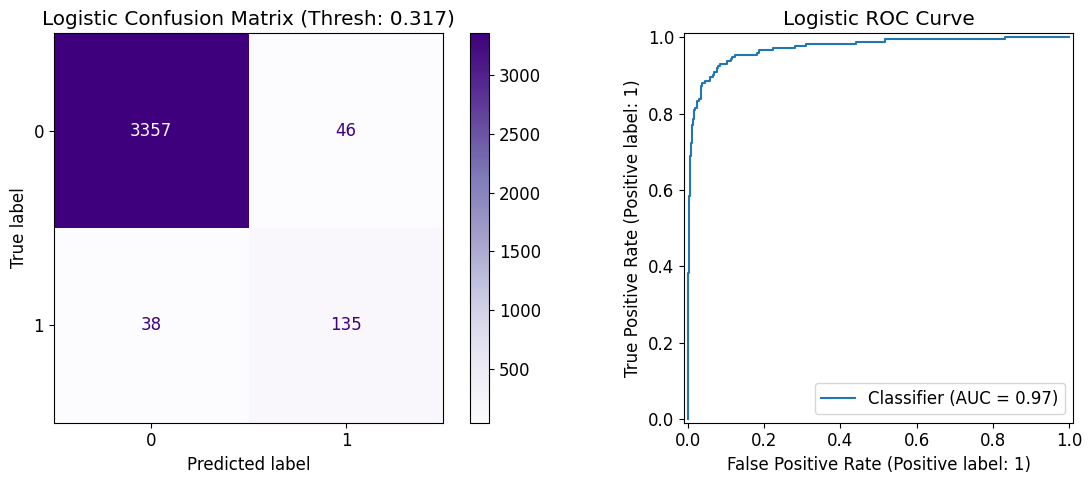

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, RocCurveDisplay

# --- (Phần code huấn luyện và tìm ngưỡng của bạn đã chạy ở trên) ---

# 1. Tạo khung vẽ 2 biểu đồ
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# 2. Vẽ Confusion Matrix với ngưỡng tối ưu (lr_opt_threshold)
# y_preds đã được bạn tính ở bước 4 trong snippet trước
ConfusionMatrixDisplay.from_predictions(y_test_array, y_preds, ax=ax1, cmap='Purples')
ax1.set_title(f"Logistic Confusion Matrix (Thresh: {lr_opt_threshold:.3f})")

# 3. Vẽ ROC Curve
# y_probs đã được bạn tính ở bước 3 trong snippet trước
RocCurveDisplay.from_predictions(y_test_array, y_probs, ax=ax2)
ax2.set_title("Logistic ROC Curve")

plt.tight_layout()
plt.show()

Fine-tune XGBoost

In [ ]:
!pip install optuna-integration[xgboost]

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 413.9/413.9 kB 14.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 kB 13.7 MB/s eta 0:00:00


In [ ]:
import xgboost as xgb
import optuna
import pandas as pd
import numpy as np
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score
from tqdm import tqdm
import warnings

warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)

def objective(trial, X, y):
    # Định nghĩa không gian tham số (Search Space)
    params = {
        'n_estimators': 5000,
        'learning_rate': 0.05,
        'max_depth': trial.suggest_int('max_depth', 3, 15),
        'subsample': trial.suggest_float('subsample', 0.4, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.4, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 20),

        # Thêm Regularization theo yêu cầu
        'alpha': trial.suggest_float('alpha', 1e-8, 10.0, log=True),  # L1
        'lambda': trial.suggest_float('lambda', 1e-8, 10.0, log=True), # L2
        'gamma': trial.suggest_float('gamma', 1e-8, 5.0, log=True),

        'random_state': 42,
        'tree_method': 'hist',
        'device':'cuda',
        'early_stopping_rounds': 200,
        'eval_metric': 'auc',
    }

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    cv_scores = []

    for train_idx, val_idx in cv.split(X, y):
        # Tách dữ liệu fold
        X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]

        model = xgb.XGBClassifier(**params)

        # Fit với early stopping
        model.fit(
            X_tr, y_tr,
            eval_set=[(X_val, y_val)],
            verbose=False
        )

        preds = model.predict_proba(X_val)[:, 1]
        cv_scores.append(roc_auc_score(y_val, preds))

    return np.mean(cv_scores)

# Thiết lập Progress Bar
n_trials = 100
pbar = tqdm(total=n_trials, desc="Fine-tuning XGBoost")

def callback(study, trial):
    pbar.update(1)

# Chạy Optuna
study = optuna.create_study(direction='maximize')
# Convert numpy arrays to pandas DataFrames/Series before passing to objective
study.optimize(lambda trial: objective(trial, pd.DataFrame(X_train_final), pd.Series(y_train)),
               n_trials=n_trials,
               callbacks=[callback])
pbar.close()

print(f"\n[INFO] Best ROC-AUC: {study.best_value:.4f}")
print(f"\n[INFO] Best Parameters: {study.best_params}")


Fine-tuning XGBoost:  21%|██        | 21/100 [15:52<53:26, 40.59s/it]

In [ ]:
import xgboost as xgb
from sklearn.metrics import roc_auc_score
params = {
    'max_depth': 15,
    'subsample': 0.9674472992781736,
    'colsample_bytree': 0.43779179903626003,
    'min_child_weight': 1,
    'reg_alpha': 7.486975656918972e-05,
    'reg_lambda': 1.1504588151482178e-05,
    'gamma': 2.750670995742273e-06
}
final_params = {**params,
                'n_estimators': 5000,
                'learning_rate': 0.01,
                'random_state': 42,
                'tree_method': 'hist',
                'device':'cuda'}
best_model = xgb.XGBClassifier(**final_params)

best_model.fit(X_train_final, y_train)

# Đánh giá cuối cùng
test_preds = best_model.predict_proba(X_test_final)[:, 1]
print(f"Final Test ROC-AUC: {roc_auc_score(y_test, test_preds):.4f}")

/usr/local/lib/python3.12/dist-packages/xgboost/core.py:751: UserWarning: [12:20:30] WARNING: /__w/xgboost/xgboost/src/common/error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


Final Test ROC-AUC: 0.9881


In [ ]:
import numpy as np
from sklearn.metrics import precision_recall_curve, f1_score, classification_report

# test_preds = best_model.predict_proba(X_test_final)[:, 1]

# 2. Tính toán Precision, Recall cho tất cả các ngưỡng có thể có
precision, recall, thresholds = precision_recall_curve(y_test, test_preds)

# 3. Tính F1-score cho từng ngưỡng
# Lưu ý: precision_recall_curve trả về precision và recall có độ dài n_thresholds + 1
# nên ta cần tính f1 thủ công trên mảng này
f1_scores = 2 * (precision * recall) / (precision + recall + 1e-10) # Thêm epsilon để tránh chia cho 0

# 4. Tìm index của F1-score cao nhất
best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]
best_f1 = f1_scores[best_idx]

print(f"--- Kết quả tối ưu hóa ngưỡng ---")
print(f"Best Threshold: {best_threshold:.4f}")
print(f"Best F1-Score:  {best_f1:.4f}")

# 5. Áp dụng ngưỡng mới để in Classification Report
final_predictions = (test_preds >= best_threshold).astype(int)

print("\n--- Classification Report với ngưỡng tối ưu ---")
print(classification_report(y_test, final_predictions))

--- Kết quả tối ưu hóa ngưỡng ---
Best Threshold: 0.0577
Best F1-Score:  0.8294

--- Classification Report với ngưỡng tối ưu ---
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      3403
           1       0.84      0.82      0.83       173

    accuracy                           0.98      3576
   macro avg       0.92      0.90      0.91      3576
weighted avg       0.98      0.98      0.98      3576



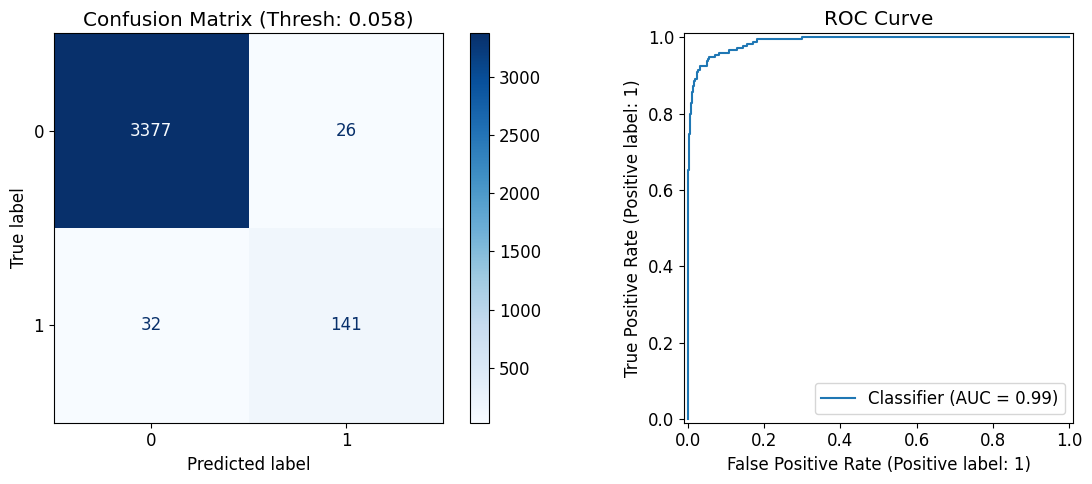

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, RocCurveDisplay

# 1. Chuyển xác suất thành nhãn 0/1 dựa trên ngưỡng tối ưu
y_pred_final = (test_preds >= best_threshold).astype(int)

# 2. Tạo khung vẽ 2 biểu đồ
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Vẽ Confusion Matrix
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_final, ax=ax1, cmap='Blues')
ax1.set_title(f"Confusion Matrix (Thresh: {best_threshold:.3f})")

# Vẽ ROC Curve
RocCurveDisplay.from_predictions(y_test, test_preds, ax=ax2)
ax2.set_title("ROC Curve")

plt.tight_layout()
plt.show()

In [ ]:
import shap
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# 1. Khởi tạo Explainer (XGBoost dùng TreeExplainer là nhanh và chính xác nhất)
explainer = shap.TreeExplainer(best_model)

# 2. Lấy một mẫu dữ liệu để giải thích (ví dụ 500 mẫu từ tập test)
X_sample = X_test_final.sample(500, random_state=42)
shap_values = explainer.shap_values(X_sample)

# Kiểm tra xem shap_values có dạng list không (tùy phiên bản XGBoost)
if isinstance(shap_values, list):
    shap_values = shap_values[1] # Lấy giá trị cho class 1 (Fake)

AttributeError: 'numpy.ndarray' object has no attribute 'sample'

2. Fine-tune LightGBM

In [ ]:
!pip install optuna-integration[lightgbm]

In [ ]:
X_train_array = np.array(X_train_final)
y_train_array = np.array(y_train)

X_test_array = np.array(X_test_final)
y_test_array = np.array(y_test)

In [ ]:
import lightgbm as lgb
import optuna
import numpy as np
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score
from tqdm import tqdm
import warnings

warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)

# Đảm bảo dữ liệu là float32 để GPU chạy nhanh hơn
X_train_arr = X_train_array.astype('float32')
y_train_arr = y_train_array

def objective(trial, X, y):
    params = {
        'objective': 'binary',
        'metric': 'auc',
        'verbosity': -1,
        'boosting_type': 'gbdt',
        'random_state': 42,
        'n_estimators': 5000,
        'learning_rate': 0.1,
        'device': 'gpu',

        # --- CHIẾN THUẬT TĂNG TỐC ---
        'max_bin': 63,               # Giảm bin để tăng tốc GPU histogram
        'gpu_use_dp': False,         # Không dùng double precision

        # Tinh chỉnh Search Space để tránh cây quá sâu gây chậm
        'num_leaves': trial.suggest_int('num_leaves', 31, 128),
        'max_depth': trial.suggest_int('max_depth', 3, 12),
        'min_child_samples': trial.suggest_int('min_child_samples', 20, 100),
        'feature_fraction': trial.suggest_float('feature_fraction', 0.6, 0.9),
        'bagging_fraction': trial.suggest_float('bagging_fraction', 0.6, 0.9),
        'bagging_freq': trial.suggest_int('bagging_freq', 1, 5),
        'lambda_l1': trial.suggest_float('lambda_l1', 1e-3, 10.0, log=True),
        'lambda_l2': trial.suggest_float('lambda_l2', 1e-3, 10.0, log=True),
    }

    # Giảm xuống 3-Fold để đạt mục tiêu 40-60s/it
    cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
    cv_scores = []

    for train_idx, val_idx in cv.split(X, y):
        X_tr, X_val = X[train_idx], X[val_idx]
        y_tr, y_val = y[train_idx], y[val_idx]

        model = lgb.LGBMClassifier(**params)
        model.fit(
            X_tr, y_tr,
            eval_set=[(X_val, y_val)],
            callbacks=[
                lgb.early_stopping(stopping_rounds=50), # Giảm để dừng sớm hơn
                lgb.log_evaluation(period=0)
            ]
        )

        preds = model.predict_proba(X_val)[:, 1]
        cv_scores.append(roc_auc_score(y_val, preds))

    return np.mean(cv_scores)

n_trials = 50
pbar = tqdm(total=n_trials, desc="Speed-Optimized LGBM Tuning")

def callback(study, trial):
    pbar.update(1)

study = optuna.create_study(direction='maximize')
study.optimize(lambda trial: objective(trial, X_train_arr, y_train_arr),
               n_trials=n_trials, callbacks=[callback])
pbar.close()

print(f"\n[SUCCESS] Best AUC: {study.best_value:.4f}")
print(f"Best Params: {study.best_params}")

In [ ]:
import lightgbm as lgb
from sklearn.metrics import roc_auc_score
# --- Huấn luyện Model cuối cùng ---
final_params = {'n_estimators': 5000,
                'learning_rate': 0.01, # Hạ LR xuống để đạt độ chính xác tối đa
                'num_leaves': 66,
                'max_depth': 9,
                'min_child_samples': 100,
                'feature_fraction': 0.7500050655431777,
                'bagging_fraction': 0.8201567845745377,
                'bagging_freq': 1,
                'lambda_l1': 0.0023673017237851516,
                'lambda_l2': 0.004728930668850107,
                'objective': 'binary',
                'metric': 'auc',
                'verbosity': -1,
                'device': 'cpu'}

best_lgbm = lgb.LGBMClassifier(**final_params)
best_lgbm.fit(X_train_final, y_train)

lgbm_test_preds = best_lgbm.predict_proba(X_test_final)[:, 1]
print(f"Final LightGBM Test ROC-AUC: {roc_auc_score(y_test, lgbm_test_preds):.4f}")

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Final LightGBM Test ROC-AUC: 0.9879


Best Threshold: 0.0739
Best F1-Score:  0.8308
--- Classification Report cho LightGBM (Threshold: 0.0739) ---
              precision    recall  f1-score   support

    Real (0)       0.99      1.00      0.99      3403
    Fake (1)       0.89      0.78      0.83       173

    accuracy                           0.98      3576
   macro avg       0.94      0.89      0.91      3576
weighted avg       0.98      0.98      0.98      3576



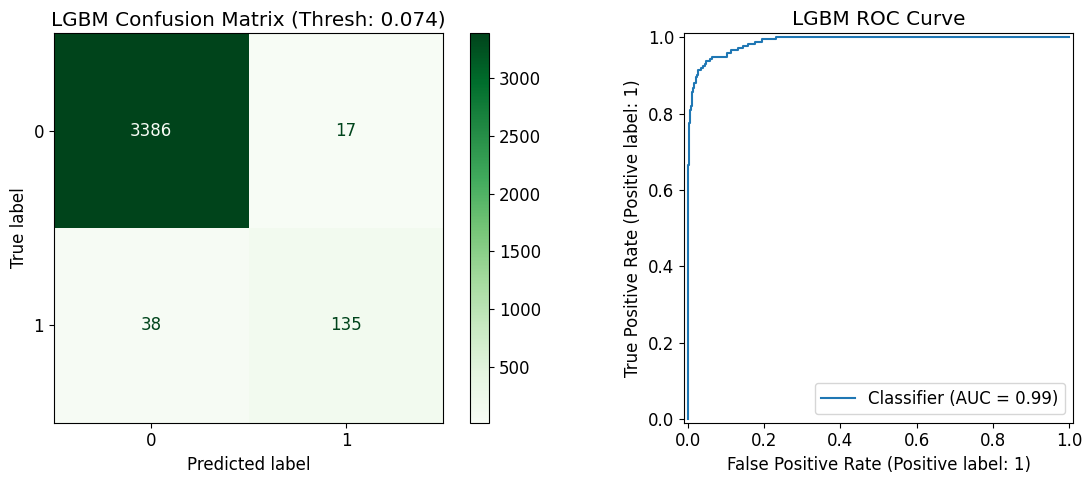

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, ConfusionMatrixDisplay, RocCurveDisplay

# 1. Tìm ngưỡng tối ưu cho F1-score
precision, recall, thresholds = precision_recall_curve(y_test, lgbm_test_preds)
f1_scores = 2 * (precision * recall) / (precision + recall + 1e-10)
best_idx = np.argmax(f1_scores)
best_threshold_lgbm = thresholds[best_idx]

print(f"Best Threshold: {best_threshold_lgbm:.4f}")
print(f"Best F1-Score:  {f1_scores[best_idx]:.4f}")

print(f"--- Classification Report cho LightGBM (Threshold: {best_threshold_lgbm:.4f}) ---")
print(classification_report(y_test, y_pred_lgbm, target_names=['Real (0)', 'Fake (1)']))

# 2. Vẽ Confusion Matrix và ROC Curve
y_pred_lgbm = (lgbm_test_preds >= best_threshold_lgbm).astype(int)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Ma trận nhầm lẫn
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_lgbm, ax=ax1, cmap='Greens')
ax1.set_title(f"LGBM Confusion Matrix (Thresh: {best_threshold_lgbm:.3f})")

# Đường cong ROC
RocCurveDisplay.from_predictions(y_test, lgbm_test_preds, ax=ax2)
ax2.set_title("LGBM ROC Curve")

plt.tight_layout()
plt.show()